<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_5_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imageio

In [2]:
def main():
    try:
        img = imageio.imread('/content/dog.png')
    except FileNotFoundError:
        img = np.zeros((200, 200), dtype=np.uint8)
        cv2.line(img, (20, 30), (180, 30), 255, 2)
        cv2.line(img, (20, 50), (180, 100), 255, 2)
        cv2.line(img, (50, 150), (150, 150), 255, 2)

    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    _, binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    edges = cv2.Canny(binary, 50, 150, apertureSize=3)

    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=50,
                            minLineLength=30, maxLineGap=10)

    color_image = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(color_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(binary, cmap='gray')
    plt.title('Binary Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(edges, cmap='gray')
    plt.title('Detected Edges (Canny)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(color_image)
    plt.title('Detected Lines (Hough Transform)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()



/tmp/ipython-input-3793650815.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('/content/dog.png')


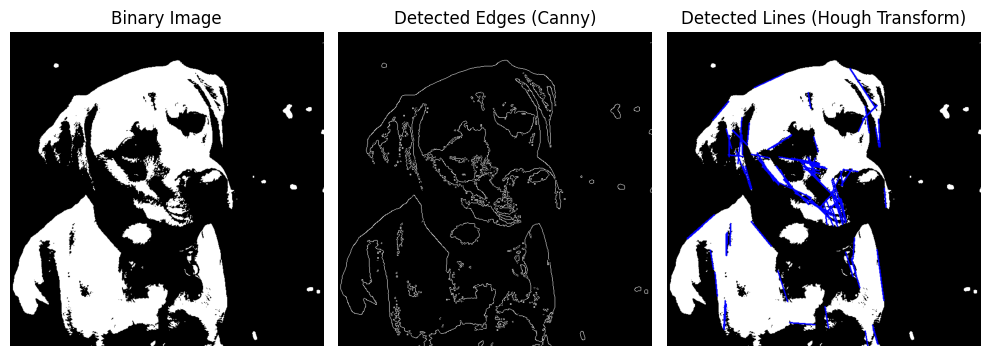

In [3]:
if __name__ == "__main__":
    main()